<a href="https://colab.research.google.com/github/MateusAFalcao/RNA-e-Deep-Learning---CESAR-School-2025.02/blob/main/TrabalhoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Trabalho Final da disciplina RNA e Deep Learning

##Grupo: Mateus Albuquerque Falcão, Thiago Roberto Cavalcanti Pimentel, Laura Silva Soares de Melo, Severino Henrique de Araújo Neto
##Emails: maf2@cesar.school, Trcp@cesar.school, lssm@cesar.school, shan@cesar.school
##Link do dataset: https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset/data


#Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pathlib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(123)

#Carregando o dataset

In [ ]:
!pip install -q kagglehub

import kagglehub
import os

caminho_dataset = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")

print(f"Os dados estão prontos na pasta: {caminho_dataset}")

data_dir = os.path.join(caminho_dataset, "Rice_Image_Dataset")

Using Colab cache for faster access to the 'rice-image-dataset' dataset.
Os dados estão prontos na pasta: /kaggle/input/rice-image-dataset


In [ ]:
caminho_base = '/kaggle/input'
caminho_correto = None

# O Python vai "andar" por todas as pastas até achar as classes
for root, dirs, files in os.walk(caminho_base):
    if 'Basmati' in dirs and 'Arborio' in dirs:
        caminho_correto = root
        break

if caminho_correto:
    data_dir = pathlib.Path(caminho_correto)
    print(f"O caminho exato é: {data_dir}")
else:
    print("Pastas não encontradas. Tente rodar a célula de download novamente.")

O caminho exato é: /kaggle/input/rice-image-dataset/Rice_Image_Dataset


O código acima foi usado para achar o path correto, porque as vezes o colab tem variações ocultas na extração dos arquivos. Aí na hora de definir o caminho, pode ser que seja definido um caminho "errado"

#Manipulação dos dados

In [ ]:
# Definindo o caminho e parâmetros básicos
data_dir = pathlib.Path('/kaggle/input/rice-image-dataset/Rice_Image_Dataset')

# REDUÇÃO DRÁSTICA DE RESOLUÇÃO: Essencial para não usar CNNs
IMG_SIZE = (32, 32)
BATCH_SIZE = 64

print("Carregando base de Treinamento...")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

print("Carregando base de Validação...")
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=IMG_SIZE,
  batch_size=BATCH_SIZE)

class_names = train_ds.class_names
print(f"Classes encontradas: {class_names}")

# Normalizando os pixels para a escala de 0 a 1
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Otimizando o carregamento em memória
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=123).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Carregando base de Treinamento...
Found 75000 files belonging to 5 classes.
Using 60000 files for training.
Carregando base de Validação...
Found 75000 files belonging to 5 classes.
Using 15000 files for validation.
Classes encontradas: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


##Vizualização de cada classe

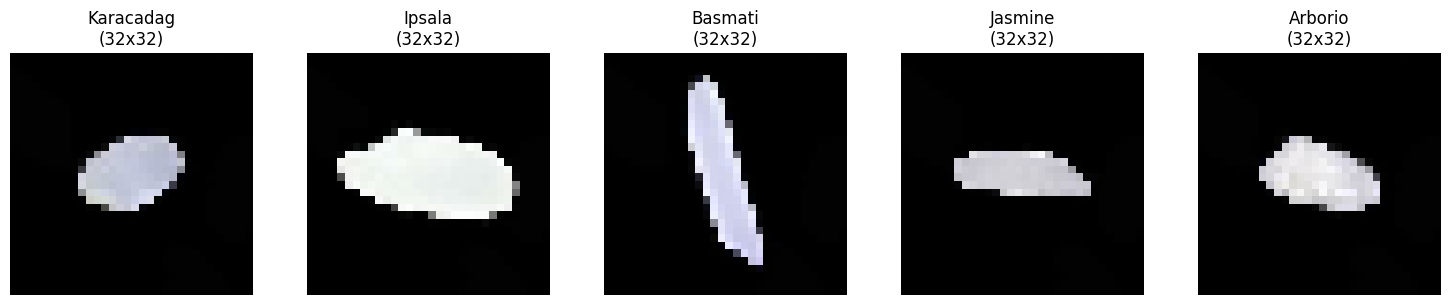

In [ ]:
imagens_amostra = []
labels_amostra = []
classes_encontradas = set()

# Iterando diretamente sobre os lotes (batches)
for images, labels in train_ds:

    # Passa por cada imagem dentro do lote de 64
    for i in range(len(labels)):
        label_id = labels[i].numpy()

        # Se a classe da imagem ainda não foi salva, nós a guardamos
        if label_id not in classes_encontradas:
            classes_encontradas.add(label_id)
            imagens_amostra.append(images[i])
            labels_amostra.append(label_id)

        # Quando são encontradas as 5 classes, a busca interna é interrompida
        if len(classes_encontradas) == 5:
            break

    # Para a busca externa (lotes) se já achou tudo
    if len(classes_encontradas) == 5:
        break

# Plotando as imagens (com um sistema de segurança no tamanho do loop)
qtd_encontrada = len(imagens_amostra)
plt.figure(figsize=(3 * qtd_encontrada, 3))

for i in range(qtd_encontrada):
    plt.subplot(1, qtd_encontrada, i + 1)

    # O matplotlib já lida automaticamente com pixels normalizados
    plt.imshow(imagens_amostra[i])

    # Busca o nome em texto da classe
    nome_da_classe = class_names[labels_amostra[i]]
    plt.title(f"{nome_da_classe}\n(32x32)", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

Senti a vontade de fazer a vizualização de cada tipo de arroz para confirmar se as imagens estavam divididas em 5 classes diferentes e poder ver a diferença entre eles. Usei o auxílio do Claude para fazer essa vizualização.

# Definição da rede

In [ ]:
model = tf.keras.Sequential([
  tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2), # Dropout ajuda a evitar overfitting
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(5, activation='softmax') # 5 neurônios de saída para as 5 classes
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,925 (1.53 MB)

 Trainable params: 401,925 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

# Treinamento

In [ ]:
EPOCHS = 15

print("Iniciando o treinamento com visualização em tempo real...")

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=EPOCHS,
)

Iniciando o treinamento com visualização em tempo real...
Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.9408 - loss: 0.1684 - val_accuracy: 0.9593 - val_loss: 0.1152
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9664 - loss: 0.0971 - val_accuracy: 0.9769 - val_loss: 0.0690
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9723 - loss: 0.0813 - val_accuracy: 0.9794 - val_loss: 0.0648
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9762 - loss: 0.0712 - val_accuracy: 0.9797 - val_loss: 0.0641
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9782 - loss: 0.0636 - val_accuracy: 0.9803 - val_loss: 0.0620
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9793 - loss: 0.0620 - val_accuracy: 0.9789 - val_loss: 0.0615
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9817 - loss: 0.0551 - val_accuracy: 0.9775 - val_loss: 0.0661
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━

## Avaliação

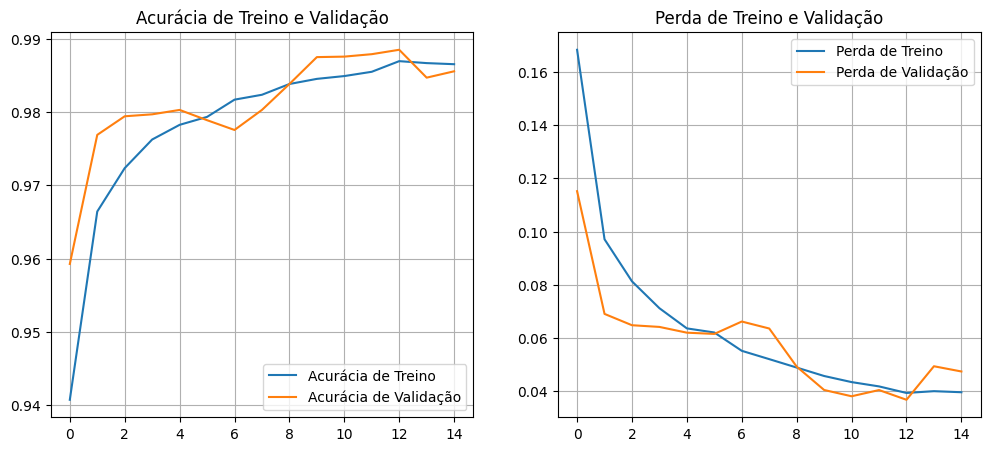

In [ ]:
# Extraindo dados do histórico
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

# Plotando Acurácia e Perda
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, label='Acurácia de Validação')
plt.legend(loc='lower right')
plt.title('Acurácia de Treino e Validação')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perda de Treino')
plt.plot(epochs_range, val_loss, label='Perda de Validação')
plt.legend(loc='upper right')
plt.title('Perda de Treino e Validação')
plt.grid(True)

plt.show()

MÉTRICAS DE PERFORMANCE EM TEXTO:
Perda (Loss) de Validação:    0.047357
Acurácia de Validação:        98.55%
Matriz de confusão:


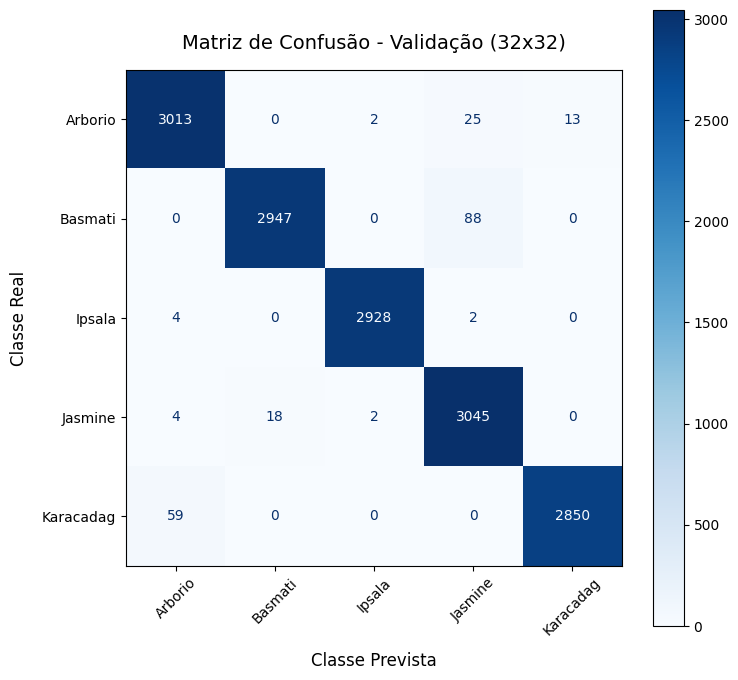

In [ ]:
loss, accuracy = model.evaluate(val_ds, verbose=0)

print("MÉTRICAS DE PERFORMANCE EM TEXTO:")
print(f"Perda (Loss) de Validação:    {loss:.6f}")
print(f"Acurácia de Validação:        {accuracy * 100:.2f}%")

y_true = []
y_pred = []

print("Matriz de confusão:")
for images, labels in val_ds:
    # Obtém as probabilidades geradas pela camada Softmax
    predicoes_prob = model.predict(images, verbose=0)
    # Seleciona o índice com a maior probabilidade (classe prevista)
    predicoes_classes = np.argmax(predicoes_prob, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicoes_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))

# O ConfusionMatrixDisplay automatiza a plotagem com os nomes textuais das classes
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title('Matriz de Confusão - Validação (32x32)', fontsize=14, pad=15)
plt.xlabel('Classe Prevista', fontsize=12, labelpad=10)
plt.ylabel('Classe Real', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.grid(False)
plt.show()

#Considerações técnicas

Na etapa de tratamento de dados, além da normalização, realizamos o redimensionamento drástico das imagens originais para 32x32 pixels. Essa decisão técnica foi fundamental para viabilizar o uso de uma arquitetura densa em um problema de imagem sem "estourar" o limite de memória com um número gigantesco de parâmetros.

O treinamento ocorreu de forma estável, com o modelo convergindo suavemente até atingir uma acurácia final em torno de 98,8%. A análise das curvas de aprendizado não apontou indícios de underfitting (dada a alta precisão alcançada) nem de overfitting, uma vez que as métricas de perda de treinamento e validação caíram juntas de forma sincronizada, auxiliadas pela eficácia da camada de Dropout. Por fim, a matriz de confusão revelou um comportamento interessante: os raros erros se concentraram entre os grãos Basmati e Jasmine (ambos parecidos, longos e finos), indicando a dificuldade esperada do modelo em separar classes de proporções geométricas quase idênticas quando expostas a uma baixa resolução.

#Considerações finais

A escolha deste dataset foi motivada por parecer com o dataset Iris, que trabalhamos com ele durante as aulas, e representar uma espécie de "avanço" em relação ao dataset Iris. Enquanto o Iris lida com dados tabulares numéricos e apenas 3 classes, este projeto elevou a complexidade ao aplicar redes neurais no campo da visão computacional, com o desafio de classificar 5 tipos distintos de arroz se baseando em matrizes de pixels de fotos.

A etapa de desenvolvimento também trouxe aprendizados práticos valiosos além do código. Durante a primeira tentativa de treinamento, obtivemos uma curiosa acurácia de 100%. Após um tempo de análise, identificamos que o problema estava no mapeamento do path do diretório: o modelo não estava aprendendo a diferenciar os tipos de arroz, ele havia carregado apenas uma única pasta, operando em um cenário isolado onde o erro era matematicamente impossível. Depois que corrigimos, a experiência real comprovou que, mesmo com a restrição de não utilizar convoluções e com perda de detalhes finos, uma rede densa é capaz de realizar classificações robustas ao aprender a diferenciar as classes através da sua "silhueta" geométrica macroscópica.